# Gross Profit vs Competitor — Preliminary EDA & Feature Engineering

Notebook ini dibuat untuk membantu checklist awal:
- validasi formula `Subtotal Price`
- cek `nunique`, terutama identifier
- membuat fitur baru dari margin, subsidy, dan competitor price
- analisis hubungan gross margin, energy grant, competitor price, dan conversion outcome

**Important:** Kolom outcome asli memakai label yang agak tidak umum: `0 = Success` dan `1 = Fail`. Kita **tidak mengubah label asli**. Untuk memudahkan analisis, notebook ini hanya menambah kolom bantu `is_success = 1 jika Convert to Order = 0`.

In [1]:
# Basic setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Update this path if your Excel file is in another folder
DATA_PATH = Path('../dataset/Gross Profit vs Competitor 0514.xlsx')

xls = pd.ExcelFile(DATA_PATH)
print(xls.sheet_names)

df_raw = pd.read_excel(DATA_PATH, sheet_name=xls.sheet_names[0])
print(df_raw.shape)
df_raw.head()

['工作表1']
(4994, 12)


,Quote ID,Product,Kw,Unit Price,Qty,Subtotal Price,Gross Margin Rate,"Convert to Order (0:Success, 1:Fail)",Energy grant amount,Competitor A,Competitor B,Competitor C
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN


## 1. Clean column names, but keep original outcome definition

Tujuannya hanya supaya coding lebih mudah. Label outcome tetap mengikuti data: `0 = Success`, `1 = Fail`.

In [2]:
def clean_col(c):
    return (str(c).strip()
            .replace(' ', '_')
            .replace('(', '')
            .replace(')', '')
            .replace(':', '')
            .replace(',', '')
            .replace('/', '_')
            .lower())

df = df_raw.copy()
df.columns = [clean_col(c) for c in df.columns]

# Rename the long outcome column to a simpler name, but do NOT change its label values.
rename_map = {
    'convert_to_order_0success_1fail': 'convert_to_order',
    'gross_margin_rate': 'gross_margin_rate',
}
df = df.rename(columns=rename_map)

print(df.columns.tolist())
df.head()

['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'convert_to_order', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c']


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN


## 2. Data overview and `nunique`

Yang perlu diperhatikan:
- `quote_id` idealnya unique untuk setiap row.
- Kalau ada duplicate `quote_id`, perlu dicek apakah memang ada multiple product/quote line, atau data duplicated.
- `competitor_b` dan `competitor_c` mungkin punya variasi sedikit; cek `nunique` dan missing value.

In [3]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100,
    'nunique': df.nunique(dropna=True)
}).sort_values(['missing_pct', 'nunique'], ascending=[False, True])
summary

,dtype,missing_count,missing_pct,nunique
competitor_c,float64,4937,98.8586,2
competitor_b,float64,4528,90.6688,1
competitor_a,float64,888,17.7813,8
convert_to_order,int64,0,0.0000,2
kw,float64,0,0.0000,11
qty,int64,0,0.0000,16
energy_grant_amount,int64,0,0.0000,22
product,object,0,0.0000,43
unit_price,float64,0,0.0000,813
subtotal_price,float64,0,0.0000,991


In [4]:
# Identifier checks
id_col = 'quote_id'
print('Rows:', len(df))
print('Unique Quote ID:', df[id_col].nunique(dropna=True))
print('Duplicated Quote ID rows:', df[id_col].duplicated(keep=False).sum())

# Show duplicated IDs if any
if df[id_col].duplicated(keep=False).any():
    display(df[df[id_col].duplicated(keep=False)].sort_values(id_col).head(20))
else:
    print('No duplicated Quote ID found.')

Rows: 4994
Unique Quote ID: 4640
Duplicated Quote ID rows: 596


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
6,Q-00525,I1,22.0000,"270,000.0000",1,"270,000.0000",0.3983,0,132000,"240,000.0000",NaN,NaN
7,Q-00525,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3983,0,222000,"360,000.0000",NaN,NaN
13,Q-01366,N1,75.0000,"845,960.0000",2,"1,691,920.0000",0.3084,0,375000,"760,000.0000","900,000.0000",NaN
21,Q-01366,N1,75.0000,"683,400.0000",2,"1,366,800.0000",0.3084,0,375000,"760,000.0000","900,000.0000",NaN
20,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
54,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
60,Q-02428,O,75.0000,"614,000.0000",1,"614,000.0000",0.4135,0,322500,NaN,NaN,NaN
59,Q-02428,S,110.0000,"1,084,000.0000",1,"1,084,000.0000",0.4135,0,528000,"1,880,000.0000",NaN,NaN
25,Q-02428,S,110.0000,"1,141,900.0000",1,"1,141,900.0000",0.4135,0,528000,"1,880,000.0000",NaN,NaN
26,Q-02428,O,75.0000,"659,000.0000",1,"659,000.0000",0.4135,0,322500,NaN,NaN,NaN


## 3. Ensure numeric columns are numeric

This prevents formula checks from failing because of text-formatted numbers.

In [5]:
num_cols = [
    'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate',
    'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c'
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Outcome distribution, keeping original coding
print(df['convert_to_order'].value_counts(dropna=False).sort_index())
print('Remember: 0 = Success, 1 = Fail')

convert_to_order
0    1267
1    3727
Name: count, dtype: int64
Remember: 0 = Success, 1 = Fail


## 4. Pastikan formula `Subtotal Price` benar

Formula expected:

\[
	ext{Subtotal Price} = 	ext{Unit Price} 	imes 	ext{Qty}
\]

Kita cek selisih aktual vs expected. Tolerance kecil dipakai untuk menghindari masalah rounding.

In [6]:
df['subtotal_expected'] = df['unit_price'] * df['qty']
df['subtotal_diff'] = df['subtotal_price'] - df['subtotal_expected']
df['subtotal_diff_abs'] = df['subtotal_diff'].abs()

TOL = 1e-6
bad_subtotal = df[df['subtotal_diff_abs'] > TOL].copy()

print('Subtotal formula mismatch rows:', len(bad_subtotal))
print('Max absolute difference:', df['subtotal_diff_abs'].max())

bad_subtotal[[
    'quote_id', 'product', 'unit_price', 'qty', 'subtotal_price',
    'subtotal_expected', 'subtotal_diff'
]].head(20)

Subtotal formula mismatch rows: 0
Max absolute difference: 4.656612873077393e-10


,quote_id,product,unit_price,qty,subtotal_price,subtotal_expected,subtotal_diff


## 5. Check possible data issues

Contoh yang perlu dilihat:
- `qty = 0` tetapi subtotal/price ada.
- gross margin rate negatif atau sangat tinggi.
- missing competitor price.

In [7]:
issue_checks = {
    'qty_zero_or_negative': (df['qty'] <= 0),
    'unit_price_zero_or_negative': (df['unit_price'] <= 0),
    'subtotal_zero_or_negative': (df['subtotal_price'] <= 0),
    'negative_gmr': (df['gross_margin_rate'] < 0),
    'gmr_above_100pct': (df['gross_margin_rate'] > 1),
}

issue_summary = pd.DataFrame({
    'issue': issue_checks.keys(),
    'row_count': [mask.sum() for mask in issue_checks.values()],
    'pct': [mask.mean() * 100 for mask in issue_checks.values()]
})
issue_summary

,issue,row_count,pct
0,qty_zero_or_negative,3,0.0601
1,unit_price_zero_or_negative,0,0.0000
2,subtotal_zero_or_negative,3,0.0601
3,negative_gmr,59,1.1814
4,gmr_above_100pct,0,0.0000


In [8]:
# Inspect suspicious rows
suspicious_mask = np.logical_or.reduce(list(issue_checks.values()))
df.loc[suspicious_mask, [
    'quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price',
    'gross_margin_rate', 'convert_to_order'
]].head(30)

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order
88,Q-05706,Q,7.5000,"145,340.0000",1,"145,340.0000",-0.0254,0
280,Q-07006,W,11.0000,"118,001.0000",1,"118,001.0000",-0.2629,0
332,Q-07371,K,37.0000,"282,217.5000",1,"282,217.5000",-0.0801,0
340,Q-07501,Q,7.5000,"146,900.0000",1,"146,900.0000",-0.0145,1
350,Q-07609,Q,7.5000,"145,340.0000",1,"145,340.0000",-0.0254,0
353,Q-07129,O,75.0000,"417,550.0000",3,"1,252,650.0000",-0.0008,0
410,Q-08029,W,11.0000,"118,001.0000",3,"354,003.0000",-0.2629,0
448,Q-08456,Q,7.5000,"147,680.0000",1,"147,680.0000",-0.0091,1
455,Q-08521,Q,7.5000,"146,900.0000",2,"293,800.0000",-0.0145,1
459,Q-08582,Q,7.5000,"146,900.0000",1,"146,900.0000",-0.0145,1


## 6. Meaning of Power Rating (`Kw`)

`Kw` is the product's performance capacity in kilowatts. In this project, it is important because higher Kw usually means:
- higher product capacity,
- higher unit price / manufacturing cost,
- possibly higher energy grant amount.

So, `kw` can be analyzed as a **technical size/capacity variable**.

In [9]:
# Relationship between Kw and price / grant
kw_summary = df.groupby('product').agg(
    n=('quote_id', 'count'),
    kw_mean=('kw', 'mean'),
    kw_median=('kw', 'median'),
    unit_price_mean=('unit_price', 'mean'),
    grant_mean=('energy_grant_amount', 'mean'),
    success_rate=('convert_to_order', lambda s: (s == 0).mean())
).sort_values('n', ascending=False)
kw_summary

,n,kw_mean,kw_median,unit_price_mean,grant_mean,success_rate
product,,,,,,
I1,1532,22.0000,22.0000,"289,568.1367","132,000.0000",0.2415
H1,1209,37.0000,37.0000,"399,124.6174","222,000.0000",0.3077
W,652,11.0000,11.0000,"192,944.1166","66,000.0000",0.1442
N1,404,75.0000,75.0000,"744,368.8361","375,000.0000",0.3713
A1,360,15.0000,15.0000,"267,957.4888","90,000.0000",0.1944
Q,339,7.5000,7.5000,"180,838.2153","45,000.0000",0.1032
J1,73,55.0000,55.0000,"741,761.0922","181,500.0000",0.2329
O1,62,75.0000,75.0000,"741,365.6555","375,000.0000",0.4677
S,47,110.0000,110.0000,"2,083,735.7872","528,000.0000",0.1702


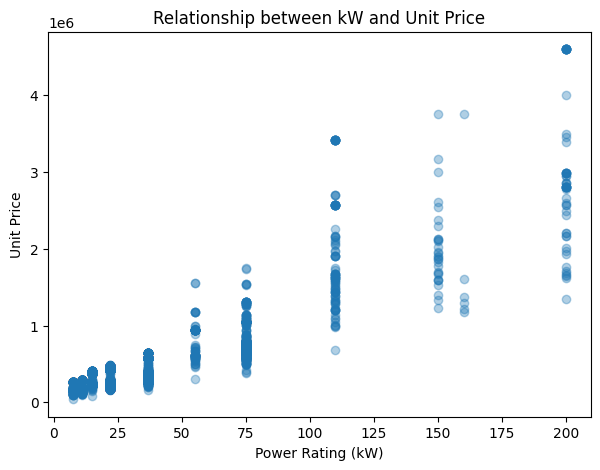

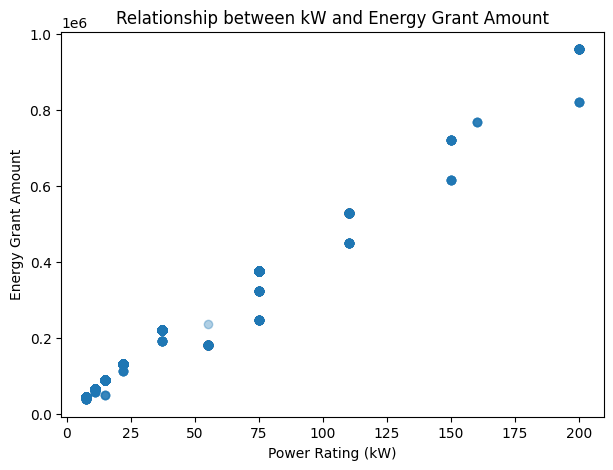

In [10]:
# Scatter: Kw vs Unit Price
plot_df = df.dropna(subset=['kw', 'unit_price'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['kw'], plot_df['unit_price'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('Unit Price')
plt.title('Relationship between kW and Unit Price')
plt.show()

# Scatter: Kw vs Energy Grant Amount
plot_df = df.dropna(subset=['kw', 'energy_grant_amount'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['kw'], plot_df['energy_grant_amount'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('Energy Grant Amount')
plt.title('Relationship between kW and Energy Grant Amount')
plt.show()

## 7. Add attributes from Gross Margin Rate formula

Gross Margin Rate formula:

\[
	ext{GMR} =
rac{	ext{Sales Revenue} - 	ext{COGS}}{	ext{Sales Revenue}}
\]

Kalau `Subtotal Price` dianggap sebagai Sales Revenue, maka bisa dibuat atribut turunan:

\[
	ext{Gross Profit Amount} = 	ext{Revenue} 	imes 	ext{GMR}
\]

\[
	ext{Estimated COGS} = 	ext{Revenue} 	imes (1 - 	ext{GMR})
\]

Ini bukan data cost asli, tapi **estimated cost based on the margin formula**.

In [11]:
df['is_success'] = (df['convert_to_order'] == 0).astype(int)  # helper only; original label still unchanged

df['gross_profit_amount'] = df['subtotal_price'] * df['gross_margin_rate']
df['estimated_cogs'] = df['subtotal_price'] * (1 - df['gross_margin_rate'])
df['unit_gross_profit'] = df['unit_price'] * df['gross_margin_rate']
df['unit_estimated_cogs'] = df['unit_price'] * (1 - df['gross_margin_rate'])

# grant features
# customer-effective quoted cost after grant, assuming grant reduces customer effective cost
# Use max denominator guard for ratio calculations
EPS = 1e-9
df['effective_subtotal_after_grant'] = df['subtotal_price'] - df['energy_grant_amount'].fillna(0)
df['grant_to_subtotal_ratio'] = df['energy_grant_amount'] / (df['subtotal_price'] + EPS)
df['grant_to_unit_price_ratio'] = df['energy_grant_amount'] / (df['unit_price'] + EPS)

df[[
    'quote_id','subtotal_price','gross_margin_rate','gross_profit_amount',
    'estimated_cogs','energy_grant_amount','effective_subtotal_after_grant'
]].head()

,quote_id,subtotal_price,gross_margin_rate,gross_profit_amount,estimated_cogs,energy_grant_amount,effective_subtotal_after_grant
0,Q-00114,"136,000.0000",0.0712,"9,683.2000","126,316.8000",66000,"70,000.0000"
1,Q-00119,"580,000.0000",0.3079,"178,582.0000","401,418.0000",222000,"358,000.0000"
2,Q-00161,"2,379,000.0000",0.4224,"1,004,889.6000","1,374,110.4000",720000,"1,659,000.0000"
3,Q-00214,"300,000.0000",0.6787,"203,610.0000","96,390.0000",132000,"168,000.0000"
4,Q-00517,"228,964.0000",0.2949,"67,521.4836","161,442.5164",132000,"96,964.0000"


## 8. Rate GMR terhadap success rate

Karena `0 = Success`, success rate dihitung sebagai proporsi row dengan `convert_to_order == 0`.

Di sini kita binning GMR untuk melihat margin range mana yang cenderung lebih sering convert.

In [12]:
# Create GMR bins by quantile, safer if distribution is skewed
# duplicates='drop' handles repeated values
valid_gmr = df.dropna(subset=['gross_margin_rate']).copy()
valid_gmr['gmr_bin'] = pd.qcut(valid_gmr['gross_margin_rate'], q=10, duplicates='drop')

gmr_success = valid_gmr.groupby('gmr_bin', observed=True).agg(
    n=('quote_id','count'),
    gmr_min=('gross_margin_rate','min'),
    gmr_max=('gross_margin_rate','max'),
    gmr_mean=('gross_margin_rate','mean'),
    success_rate=('is_success','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_grant=('energy_grant_amount','mean')
).reset_index()

gmr_success

,gmr_bin,n,gmr_min,gmr_max,gmr_mean,success_rate,avg_unit_price,avg_grant
0,"(-1.3239999999999998, 0.118]",513,-1.3226,0.1182,0.0606,0.5283,"229,039.0132","107,082.6901"
1,"(0.118, 0.205]",487,0.1187,0.2049,0.1708,0.3101,"261,170.7747","113,358.8090"
2,"(0.205, 0.291]",499,0.2051,0.2912,0.2489,0.5471,"390,109.8271","193,968.2565"
3,"(0.291, 0.352]",501,0.2915,0.3518,0.3229,0.3912,"488,039.1017","238,137.7246"
4,"(0.352, 0.398]",497,0.3538,0.3979,0.3804,0.2133,"420,627.5154","197,228.4105"
5,"(0.398, 0.426]",499,0.3980,0.4257,0.4085,0.1222,"369,666.3639","174,027.2946"
6,"(0.426, 0.452]",501,0.4259,0.4525,0.4393,0.1178,"372,056.7687","189,904.0319"
7,"(0.452, 0.498]",501,0.4531,0.4983,0.4747,0.1657,"423,470.1122","197,942.9142"
8,"(0.498, 0.619]",535,0.4991,0.6191,0.5868,0.0953,"657,978.0810","195,558.4673"
9,"(0.619, 0.921]",461,0.6193,0.9211,0.6581,0.0347,"718,636.6108","222,887.6356"


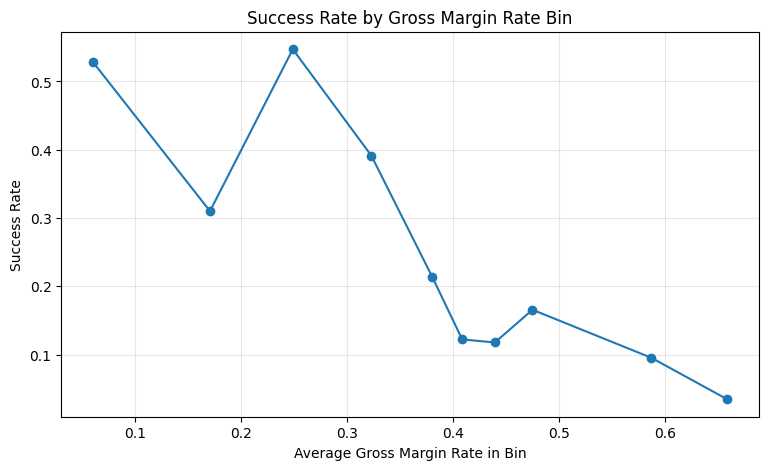

In [13]:
plt.figure(figsize=(9,5))
plt.plot(gmr_success['gmr_mean'], gmr_success['success_rate'], marker='o')
plt.xlabel('Average Gross Margin Rate in Bin')
plt.ylabel('Success Rate')
plt.title('Success Rate by Gross Margin Rate Bin')
plt.grid(True, alpha=0.3)
plt.show()

## 9. Margin threshold: margin berapa yang convert ke kemenangan?

Cara sederhana:
- coba banyak cutoff GMR,
- hitung success rate di bawah dan di atas cutoff,
- cari range/cutoff yang menghasilkan success rate tertinggi.

Interpretasi hati-hati: ini descriptive, belum tentu causal.

In [14]:
thresholds = np.arange(-0.5, 1.01, 0.01)
rows = []
for t in thresholds:
    below = df[df['gross_margin_rate'] <= t]
    above = df[df['gross_margin_rate'] > t]
    rows.append({
        'threshold_gmr': t,
        'n_below_or_equal': len(below),
        'success_rate_below_or_equal': below['is_success'].mean() if len(below) else np.nan,
        'n_above': len(above),
        'success_rate_above': above['is_success'].mean() if len(above) else np.nan,
        'difference_below_minus_above': (below['is_success'].mean() - above['is_success'].mean()) if len(below) and len(above) else np.nan
    })

threshold_df = pd.DataFrame(rows)
threshold_df.sort_values('difference_below_minus_above', ascending=False).head(15)

,threshold_gmr,n_below_or_equal,success_rate_below_or_equal,n_above,success_rate_above,difference_below_minus_above
47,-0.0300,22,0.9545,4972,0.2506,0.7039
46,-0.0400,21,0.9524,4973,0.2508,0.7016
45,-0.0500,20,0.9500,4974,0.2509,0.6991
44,-0.0600,20,0.9500,4974,0.2509,0.6991
48,-0.0200,42,0.9286,4952,0.2480,0.6806
43,-0.0700,11,0.9091,4983,0.2523,0.6568
42,-0.0800,9,0.8889,4985,0.2526,0.6363
38,-0.1200,7,0.8571,4987,0.2529,0.6043
39,-0.1100,7,0.8571,4987,0.2529,0.6043
40,-0.1000,7,0.8571,4987,0.2529,0.6043


In [15]:
# Alternative: best GMR bin by success rate, with enough samples
MIN_N = 50
best_bins = gmr_success[gmr_success['n'] >= MIN_N].sort_values('success_rate', ascending=False)
best_bins.head(10)

,gmr_bin,n,gmr_min,gmr_max,gmr_mean,success_rate,avg_unit_price,avg_grant
2,"(0.205, 0.291]",499,0.2051,0.2912,0.2489,0.5471,"390,109.8271","193,968.2565"
0,"(-1.3239999999999998, 0.118]",513,-1.3226,0.1182,0.0606,0.5283,"229,039.0132","107,082.6901"
3,"(0.291, 0.352]",501,0.2915,0.3518,0.3229,0.3912,"488,039.1017","238,137.7246"
1,"(0.118, 0.205]",487,0.1187,0.2049,0.1708,0.3101,"261,170.7747","113,358.8090"
4,"(0.352, 0.398]",497,0.3538,0.3979,0.3804,0.2133,"420,627.5154","197,228.4105"
7,"(0.452, 0.498]",501,0.4531,0.4983,0.4747,0.1657,"423,470.1122","197,942.9142"
5,"(0.398, 0.426]",499,0.3980,0.4257,0.4085,0.1222,"369,666.3639","174,027.2946"
6,"(0.426, 0.452]",501,0.4259,0.4525,0.4393,0.1178,"372,056.7687","189,904.0319"
8,"(0.498, 0.619]",535,0.4991,0.6191,0.5868,0.0953,"657,978.0810","195,558.4673"
9,"(0.619, 0.921]",461,0.6193,0.9211,0.6581,0.0347,"718,636.6108","222,887.6356"


## 10. Energy grant amount vs margin / estimated cost / competitor price

Pertanyaan yang bisa dijawab:
- Apakah quote dengan grant lebih tinggi lebih sering success?
- Apakah grant tinggi biasanya muncul pada product/kW tertentu?
- Apakah grant bisa mengurangi effective price sehingga tetap menang walaupun quoted price tinggi?

In [16]:
# Grant bins and success rate
grant_df = df.dropna(subset=['energy_grant_amount']).copy()
grant_df['grant_bin'] = pd.qcut(grant_df['energy_grant_amount'], q=10, duplicates='drop')

grant_success = grant_df.groupby('grant_bin', observed=True).agg(
    n=('quote_id','count'),
    grant_min=('energy_grant_amount','min'),
    grant_max=('energy_grant_amount','max'),
    grant_mean=('energy_grant_amount','mean'),
    kw_mean=('kw','mean'),
    gmr_mean=('gross_margin_rate','mean'),
    unit_price_mean=('unit_price','mean'),
    success_rate=('is_success','mean')
).reset_index()

grant_success

,grant_bin,n,grant_min,grant_max,grant_mean,kw_mean,gmr_mean,unit_price_mean,success_rate
0,"(38699.999, 66000.0]",1049,38700,66000,"58,272.5834",9.7812,0.2082,"186,694.3992",0.1392
1,"(66000.0, 132000.0]",1901,90000,132000,"123,958.8006",20.6744,0.4045,"285,839.3337",0.2315
2,"(132000.0, 181500.0]",86,181500,181500,"181,500.0000",55.0000,0.3723,"778,137.5101",0.2442
3,"(181500.0, 222000.0]",1226,190920,222000,"221,569.0375",37.0000,0.4672,"398,759.0170",0.3067
4,"(222000.0, 375000.0]",531,236500,375000,"364,315.4426",74.9623,0.3731,"768,855.5217",0.3917
5,"(375000.0, 960000.0]",201,451000,960000,"673,169.1542",144.3284,0.3890,"2,268,457.8239",0.3781


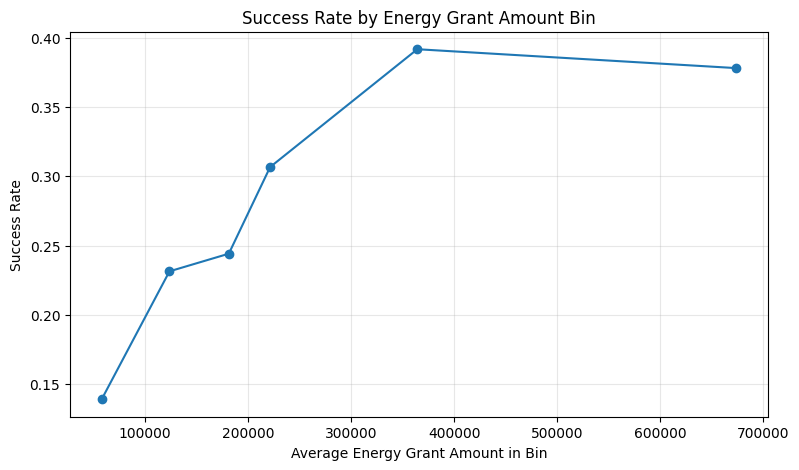

In [17]:
plt.figure(figsize=(9,5))
plt.plot(grant_success['grant_mean'], grant_success['success_rate'], marker='o')
plt.xlabel('Average Energy Grant Amount in Bin')
plt.ylabel('Success Rate')
plt.title('Success Rate by Energy Grant Amount Bin')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Correlation overview for numeric variables
corr_cols = [
    'kw','unit_price','qty','subtotal_price','gross_margin_rate',
    'gross_profit_amount','estimated_cogs','energy_grant_amount',
    'grant_to_subtotal_ratio','effective_subtotal_after_grant',
    'competitor_a','competitor_b','competitor_c','is_success'
]

corr = df[corr_cols].corr(numeric_only=True)
corr['is_success'].sort_values(ascending=False)

is_success                        1.0000
competitor_c                      0.3911
qty                               0.2912
estimated_cogs                    0.2237
energy_grant_amount               0.1516
kw                                0.1468
subtotal_price                    0.1076
competitor_a                      0.0940
effective_subtotal_after_grant    0.0868
grant_to_subtotal_ratio           0.0382
unit_price                       -0.0229
gross_profit_amount              -0.0619
gross_margin_rate                -0.3479
competitor_b                         NaN
Name: is_success, dtype: float64

## 11. Competitor analysis and company win distribution

Buat fitur perbandingan price dengan competitor:
- `price_gap_vs_competitor = company_unit_price - competitor_price`
- `price_gap_pct_vs_competitor = (company_unit_price - competitor_price) / competitor_price`
- negatif berarti company price lebih murah dari competitor.
- positif berarti company price lebih mahal dari competitor.

Karena competitor price mungkin per-unit benchmark, perbandingan paling aman dimulai dengan `Unit Price` vs competitor columns. Kalau ternyata competitor price adalah total quote price, perlu dikonfirmasi saat interview.

In [19]:
competitors = ['competitor_a', 'competitor_b', 'competitor_c']

for comp in competitors:
    df[f'price_gap_vs_{comp}'] = df['unit_price'] - df[comp]
    df[f'price_gap_pct_vs_{comp}'] = df[f'price_gap_vs_{comp}'] / (df[comp] + EPS)
    df[f'is_cheaper_than_{comp}'] = (df['unit_price'] < df[comp]).astype('Int64')
    df.loc[df[comp].isna(), f'is_cheaper_than_{comp}'] = pd.NA

# Best available competitor benchmark: minimum competitor price across A/B/C
# If the company's unit price is lower than min competitor price, it is the cheapest among available benchmark.
df['min_competitor_price'] = df[competitors].min(axis=1, skipna=True)
df['avg_competitor_price'] = df[competitors].mean(axis=1, skipna=True)
df['available_competitor_count'] = df[competitors].notna().sum(axis=1)

df['price_gap_vs_min_competitor'] = df['unit_price'] - df['min_competitor_price']
df['price_gap_pct_vs_min_competitor'] = df['price_gap_vs_min_competitor'] / (df['min_competitor_price'] + EPS)
df['is_cheaper_than_min_competitor'] = (df['unit_price'] < df['min_competitor_price']).astype('Int64')
df.loc[df['min_competitor_price'].isna(), 'is_cheaper_than_min_competitor'] = pd.NA

# Effective price after grant compared with competitor benchmark
df['effective_unit_price_after_grant'] = (df['subtotal_price'] - df['energy_grant_amount'].fillna(0)) / df['qty'].replace(0, np.nan)
df['effective_gap_pct_vs_min_competitor'] = (df['effective_unit_price_after_grant'] - df['min_competitor_price']) / (df['min_competitor_price'] + EPS)

df[[
    'quote_id','unit_price','competitor_a','competitor_b','competitor_c',
    'min_competitor_price','price_gap_pct_vs_min_competitor',
    'effective_unit_price_after_grant','effective_gap_pct_vs_min_competitor',
    'convert_to_order'
]].head(10)

,quote_id,unit_price,competitor_a,competitor_b,competitor_c,min_competitor_price,price_gap_pct_vs_min_competitor,effective_unit_price_after_grant,effective_gap_pct_vs_min_competitor,convert_to_order
0,Q-00114,"136,000.0000",NaN,NaN,NaN,NaN,NaN,"70,000.0000",NaN,0
1,Q-00119,"290,000.0000","360,000.0000",NaN,NaN,"360,000.0000",-0.1944,"179,000.0000",-0.5028,0
2,Q-00161,"2,379,000.0000",NaN,NaN,NaN,NaN,NaN,"1,659,000.0000",NaN,1
3,Q-00214,"300,000.0000","240,000.0000",NaN,NaN,"240,000.0000",0.2500,"168,000.0000",-0.3000,0
4,Q-00517,"228,964.0000","240,000.0000",NaN,NaN,"240,000.0000",-0.0460,"96,964.0000",-0.5960,0
5,Q-00521,"1,283,500.0000","760,000.0000","900,000.0000",NaN,"760,000.0000",0.6888,"908,500.0000",0.1954,1
6,Q-00525,"270,000.0000","240,000.0000",NaN,NaN,"240,000.0000",0.1250,"138,000.0000",-0.4250,0
7,Q-00525,"290,000.0000","360,000.0000",NaN,NaN,"360,000.0000",-0.1944,"179,000.0000",-0.5028,0
8,Q-00167,"775,970.0000","760,000.0000","900,000.0000",NaN,"760,000.0000",0.0210,"400,970.0000",-0.4724,0
9,Q-01157,"1,703,700.0000",NaN,NaN,NaN,NaN,NaN,"983,700.0000",NaN,0


In [20]:
# General win distribution: success rate by price competitiveness group
comp_df = df[df['available_competitor_count'] > 0].copy()

# Price gap group: cheaper, similar, more expensive
# Similar means within +/- 5% of cheapest competitor price.
conditions = [
    comp_df['price_gap_pct_vs_min_competitor'] < -0.05,
    comp_df['price_gap_pct_vs_min_competitor'].between(-0.05, 0.05, inclusive='both'),
    comp_df['price_gap_pct_vs_min_competitor'] > 0.05,
]
choices = ['Company >5% cheaper', 'Similar price ±5%', 'Company >5% more expensive']
comp_df['price_position_vs_min_competitor'] = np.select(conditions, choices, default='Unknown')

price_position_summary = comp_df.groupby('price_position_vs_min_competitor').agg(
    n=('quote_id','count'),
    success_rate=('is_success','mean'),
    avg_gmr=('gross_margin_rate','mean'),
    avg_grant=('energy_grant_amount','mean'),
    avg_kw=('kw','mean'),
    avg_price_gap_pct=('price_gap_pct_vs_min_competitor','mean')
).sort_values('success_rate', ascending=False)

price_position_summary

,n,success_rate,avg_gmr,avg_grant,avg_kw,avg_price_gap_pct
price_position_vs_min_competitor,,,,,,
Company >5% cheaper,874,0.7941,0.2541,"263,061.2128",49.9073,-0.1935
Similar price ±5%,651,0.2304,0.4342,"239,391.7051",42.7227,0.0068
Company >5% more expensive,2638,0.0967,0.4400,"159,676.8764",28.4640,0.4820


In [21]:
# In what sector/product does the company win?
product_win_summary = df.groupby('product').agg(
    n=('quote_id','count'),
    success_count=('is_success','sum'),
    success_rate=('is_success','mean'),
    avg_kw=('kw','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_gmr=('gross_margin_rate','mean'),
    avg_grant=('energy_grant_amount','mean'),
    avg_competitor_count=('available_competitor_count','mean'),
    avg_gap_pct_vs_min_comp=('price_gap_pct_vs_min_competitor','mean')
).sort_values(['success_rate','n'], ascending=[False, False])

product_win_summary

,n,success_count,success_rate,avg_kw,avg_unit_price,avg_gmr,avg_grant,avg_competitor_count,avg_gap_pct_vs_min_comp
product,,,,,,,,,
G,7,7,1.0000,150.0000,"1,522,499.8800",0.2226,"615,000.0000",0.0000,NaN
C1,5,5,1.0000,160.0000,"1,331,799.7480",0.2777,"768,000.0000",1.0000,-0.3658
G1,1,1,1.0000,200.0000,"2,806,000.0000",0.4272,"960,000.0000",1.0000,0.4030
L,1,1,1.0000,55.0000,"300,600.0000",0.0352,"236,500.0000",0.0000,NaN
I,7,5,0.7143,200.0000,"1,868,206.4571",0.2420,"820,000.0000",0.0000,NaN
N,10,7,0.7000,75.0000,"740,296.1600",0.3219,"322,500.0000",0.0000,NaN
V,6,4,0.6667,110.0000,"1,891,723.3333",0.4356,"528,000.0000",1.0000,0.0062
C,10,6,0.6000,110.0000,"1,517,406.1500",0.2452,"451,000.0000",0.0000,NaN
Q1,10,6,0.6000,75.0000,"1,033,067.3270",0.2912,"247,500.0000",0.0000,NaN


In [22]:
# Win characteristics: compare success vs fail
win_fail_summary = df.groupby('convert_to_order').agg(
    n=('quote_id','count'),
    success_rate=('is_success','mean'),
    avg_kw=('kw','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_subtotal=('subtotal_price','mean'),
    avg_gmr=('gross_margin_rate','mean'),
    avg_gross_profit=('gross_profit_amount','mean'),
    avg_estimated_cogs=('estimated_cogs','mean'),
    avg_grant=('energy_grant_amount','mean'),
    avg_grant_to_subtotal=('grant_to_subtotal_ratio','mean'),
    avg_gap_pct_vs_min_comp=('price_gap_pct_vs_min_competitor','mean'),
    avg_effective_gap_pct_vs_min_comp=('effective_gap_pct_vs_min_competitor','mean')
)

win_fail_summary.index = win_fail_summary.index.map({0: 'Success (0)', 1: 'Fail (1)'})
win_fail_summary

,n,success_rate,avg_kw,avg_unit_price,avg_subtotal,avg_gmr,avg_gross_profit,avg_estimated_cogs,avg_grant,avg_grant_to_subtotal,avg_gap_pct_vs_min_comp,avg_effective_gap_pct_vs_min_comp
convert_to_order,,,,,,,,,,,,
Success (0),1267,1.0000,41.4313,"414,020.7409","615,204.6327",0.2692,"173,411.6729","441,792.9598","219,399.1002","331,491,712,707.6602",-0.0534,-0.5082
Fail (1),3727,0.0000,31.1178,"438,604.6163","463,835.1275",0.4098,"215,804.5757","248,030.5518","170,326.2946",0.4089,0.3803,-0.1582


## 12. Possible analysis list and how to do it

This table is for report/interview planning.

In [23]:
analysis_plan = pd.DataFrame([
    {
        'Question': 'Is Subtotal Price formula correct?',
        'Method': 'Check Subtotal Price = Unit Price × Qty; report mismatch count and max difference.',
        'Output': 'Data quality table; suspicious rows if mismatch exists.'
    },
    {
        'Question': 'Are identifiers unique?',
        'Method': 'nunique and duplicated check on Quote ID.',
        'Output': 'Unique ID count, duplicate row list if any.'
    },
    {
        'Question': 'How does gross margin relate to success?',
        'Method': 'Create GMR bins and calculate success rate for each bin; test thresholds.',
        'Output': 'Success rate by GMR bin and possible margin range.'
    },
    {
        'Question': 'Can GMR formula create new features?',
        'Method': 'Use Revenue × GMR for gross profit amount and Revenue × (1-GMR) for estimated COGS.',
        'Output': 'Gross profit amount, estimated COGS, unit gross profit, unit estimated COGS.'
    },
    {
        'Question': 'Does energy grant help conversion?',
        'Method': 'Bin grant amount; compare success rate and control by product/kW if possible.',
        'Output': 'Success rate by grant bin; grant-to-subtotal ratio.'
    },
    {
        'Question': 'Does grant compensate for higher price?',
        'Method': 'Calculate effective price after grant and compare to competitor prices.',
        'Output': 'Effective price gap vs competitor and success rate.'
    },
    {
        'Question': 'How competitive is company price?',
        'Method': 'Compare Unit Price vs Competitor A/B/C; calculate price gap percentage.',
        'Output': 'Company cheaper/similar/more expensive groups and success rate.'
    },
    {
        'Question': 'Where does company win?',
        'Method': 'Group by Product and price position; compare success rate, margin, grant, kW.',
        'Output': 'Product-level win profile.'
    },
    {
        'Question': 'What makes successful quotes stand out?',
        'Method': 'Compare means/medians between Success (0) and Fail (1).',
        'Output': 'Win vs fail profile table.'
    },
    {
        'Question': 'Can we build a simple prediction model?',
        'Method': 'Optional logistic regression / decision tree using engineered features.',
        'Output': 'Feature importance or coefficient direction, not just accuracy.'
    },
])

analysis_plan

,Question,Method,Output
0,Is Subtotal Price formula correct?,Check Subtotal Price = Unit Price × Qty; repor...,Data quality table; suspicious rows if mismatc...
1,Are identifiers unique?,nunique and duplicated check on Quote ID.,"Unique ID count, duplicate row list if any."
2,How does gross margin relate to success?,Create GMR bins and calculate success rate for...,Success rate by GMR bin and possible margin ra...
3,Can GMR formula create new features?,Use Revenue × GMR for gross profit amount and ...,"Gross profit amount, estimated COGS, unit gros..."
4,Does energy grant help conversion?,Bin grant amount; compare success rate and con...,Success rate by grant bin; grant-to-subtotal r...
5,Does grant compensate for higher price?,Calculate effective price after grant and comp...,Effective price gap vs competitor and success ...
6,How competitive is company price?,Compare Unit Price vs Competitor A/B/C; calcul...,Company cheaper/similar/more expensive groups ...
7,Where does company win?,Group by Product and price position; compare s...,Product-level win profile.
8,What makes successful quotes stand out?,Compare means/medians between Success (0) and ...,Win vs fail profile table.
9,Can we build a simple prediction model?,Optional logistic regression / decision tree u...,"Feature importance or coefficient direction, n..."


## 13. Optional simple model for interpretation

This is not required for the first exploration, but useful if you want to identify important predictors. The model predicts `is_success`, while original outcome label is preserved.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

feature_cols = [
    'product','kw','unit_price','qty','subtotal_price','gross_margin_rate',
    'gross_profit_amount','estimated_cogs','energy_grant_amount',
    'grant_to_subtotal_ratio','available_competitor_count',
    'price_gap_pct_vs_min_competitor','effective_gap_pct_vs_min_competitor'
]

model_df = df[feature_cols + ['is_success']].copy()
model_df = model_df.dropna(subset=['is_success'])

X = model_df[feature_cols]
y = model_df['is_success']

cat_features = ['product']
num_features = [c for c in feature_cols if c not in cat_features]

preprocess = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features)
])

clf = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Fail', 'Success']))
print('ROC AUC:', roc_auc_score(y_test, y_prob))
print('Confusion matrix:', confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        Fail       0.90      0.84      0.87       746
     Success       0.61      0.74      0.67       253

    accuracy                           0.81       999
   macro avg       0.76      0.79      0.77       999
weighted avg       0.83      0.81      0.82       999

ROC AUC: 0.8625263592917164
Confusion matrix: [[627 119]
 [ 66 187]]


In [25]:
# Logistic regression coefficients for interpretation
pre = clf.named_steps['preprocess']
model = clf.named_steps['model']

feature_names = []
feature_names.extend(pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features))
feature_names.extend(num_features)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient_for_success': model.coef_[0]
}).sort_values('coefficient_for_success', ascending=False)

coef_df

,feature,coefficient_for_success
0,product_A,1.9252
44,qty,1.5485
27,product_O,1.3441
42,kw,1.3266
32,product_Q1,1.0522
37,product_V,1.0396
8,product_E,1.0344
24,product_M1,1.0333
22,product_L1,1.0008
36,product_U,0.9534


## 14. Save engineered dataset and key summary tables

This creates Excel outputs from the notebook analysis.

In [26]:
!pip install xlsxwriter

In [27]:
OUTPUT_PATH = Path('../outputs/gross_profit_competitor_eda_outputs.xlsx')

with pd.ExcelWriter(OUTPUT_PATH, engine='xlsxwriter') as writer:
    df.to_excel(writer, sheet_name='engineered_data', index=False)
    summary.to_excel(writer, sheet_name='data_overview')
    issue_summary.to_excel(writer, sheet_name='data_issues', index=False)
    gmr_success.to_excel(writer, sheet_name='gmr_success_bins', index=False)
    threshold_df.to_excel(writer, sheet_name='gmr_thresholds', index=False)
    grant_success.to_excel(writer, sheet_name='grant_success_bins', index=False)
    price_position_summary.to_excel(writer, sheet_name='price_position')
    product_win_summary.to_excel(writer, sheet_name='product_win_summary')
    win_fail_summary.to_excel(writer, sheet_name='win_fail_summary')
    analysis_plan.to_excel(writer, sheet_name='analysis_plan', index=False)

print(f'Saved: {OUTPUT_PATH.resolve()}')

Saved: C:\Users\surya\Downloads\analysis\outputs\gross_profit_competitor_eda_outputs.xlsx
